#  Statistics with Python: Hypothesis Testing Activity  <hr style="border:2.5px solid #126782"></hr>

<b> Daniel Udasco </b>
<br> 3rd Year Comp Eng Tech Student

# Import Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import (shapiro, ttest_1samp, ttest_ind, ttest_rel, f)
from statsmodels.stats.power import TTestPower
from IPython.display import display, HTML

# Import "Beginner_Climate_Change_Dataset_20_Features_1200_Rows.csv" Dataset

In [25]:
df = pd.read_csv("unprocessed/Beginner_Climate_Change_Dataset_20_Features_1200_Rows.csv")

df.head()

,year,country,global_avg_temperature,temperature_anomaly,max_temperature,min_temperature,co2_concentration_ppm,annual_rainfall_mm,sea_level_rise_mm,sea_surface_temperature,heatwave_days,drought_index,flood_events_count,forest_cover_percent,deforestation_rate,fossil_fuel_consumption,renewable_energy_share,air_quality_index,predicted_temperature_2050,climate_risk_index
0,2018,Germany,14.03,1.16,37.02,4.31,387.85,814.11,2.14,14.38,50,0.85,11,64.33,1.26,28.14,42.30,148,3.30,23.69
1,2008,India,15.03,1.05,32.25,-0.44,407.24,735.61,4.19,15.33,37,1.01,11,42.69,0.62,86.40,53.65,50,2.63,70.10
2,1994,Pakistan,14.86,1.24,41.57,1.08,450.54,1982.92,6.46,15.90,27,4.59,1,65.47,2.08,34.95,47.20,107,1.33,34.74
3,2022,USA,15.29,1.19,32.17,1.68,415.42,1162.01,3.37,17.26,25,4.29,6,44.34,2.15,77.11,36.65,129,2.51,45.59
4,1987,Australia,13.75,1.32,40.99,10.38,403.42,1170.25,4.64,16.62,41,1.00,4,14.18,0.76,37.27,50.35,149,2.87,55.77


# Dataset Information

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   year                        1200 non-null   int64  
 1   country                     1200 non-null   object 
 2   global_avg_temperature      1200 non-null   float64
 3   temperature_anomaly         1200 non-null   float64
 4   max_temperature             1200 non-null   float64
 5   min_temperature             1200 non-null   float64
 6   co2_concentration_ppm       1200 non-null   float64
 7   annual_rainfall_mm          1200 non-null   float64
 8   sea_level_rise_mm           1200 non-null   float64
 9   sea_surface_temperature     1200 non-null   float64
 10  heatwave_days               1200 non-null   int64  
 11  drought_index               1200 non-null   float64
 12  flood_events_count          1200 non-null   int64  
 13  forest_cover_percent        1200 

In [27]:
df.shape

(1200, 20)

# Descriptive Statistics

In [28]:
df = df[[
    "global_avg_temperature",
    "sea_surface_temperature"
]]

df.head()

,global_avg_temperature,sea_surface_temperature
0,14.03,14.38
1,15.03,15.33
2,14.86,15.90
3,15.29,17.26
4,13.75,16.62


In [29]:
df.describe()

,global_avg_temperature,sea_surface_temperature
count,1200.000000,1200.000000
mean,14.492850,16.472383
std,0.594588,1.470498
min,12.420000,11.320000
25%,14.080000,15.457500
50%,14.510000,16.460000
75%,14.910000,17.440000
max,16.140000,20.880000


# Boxplot for Outlier Detection

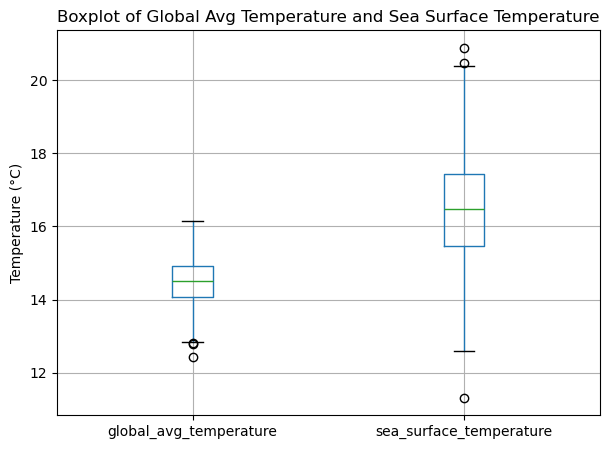

In [30]:
plt.figure(figsize=(7,5))

df.boxplot()

plt.title("Boxplot of Global Avg Temperature and Sea Surface Temperature")
plt.ylabel("Temperature (°C)")

plt.show()

# Shapiro-Wilk Normality Test

In [31]:
temp_data = df["global_avg_temperature"].dropna()

stat, p = shapiro(temp_data)

print("Shapiro Statistic:", stat)
print("p-value:", p)

if p > 0.05:
    print("Data is normally distributed.")
else:
    print("Data is not normally distributed.")

Shapiro Statistic: 0.9989700998540194
p-value: 0.7459929845171142
Data is normally distributed.


In [32]:
stat_global, p_global = shapiro(df["global_avg_temperature"])
stat_sea, p_sea = shapiro(df["sea_surface_temperature"])

text = f"""
Global Temperature:
W_stat: {stat_global:.4f}
P-value: {p_global:.4f}
Normal data

Sea Surface Temperature:
W_stat: {stat_sea:.4f}
P-value: {p_sea:.4f}
Normal data
"""

display(HTML(f"<pre style='border:1px solid black;background:#f2f2f2;padding:10px;width:250px'>{text}</pre>"))

# One-Sample T-Test

In [33]:
t_stat, p_value = ttest_1samp(temp_data, 15)

print("T-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

T-statistic: -29.546827131342635
p-value: 1.3310389412482153e-144
Reject the null hypothesis.


# Cohen’s d (Effect Size)

In [34]:
sample_mean = temp_data.mean()
pop_mean = 15
sample_std = temp_data.std()

d = abs((sample_mean - pop_mean) / sample_std)

print("Cohen's d:", d)

Cohen's d: 0.8529434298989993


# Power Analysis

In [35]:
power = TTestPower().power(
    effect_size=d,
    nobs=len(temp_data),
    alpha=0.05,
    alternative="two-sided"
)

print("Statistical Power:", power)
print("Statistical Power (%):", power*100)

Statistical Power: 1.0
Statistical Power (%): 100.0


In [36]:
sample_mean = df["global_avg_temperature"].mean()
pop_mean = 15
sample_std = df["global_avg_temperature"].std()

d = abs((sample_mean - pop_mean) / sample_std)

power = TTestPower().power(
    effect_size=d,
    nobs=len(df["global_avg_temperature"]),
    alpha=0.05,
    alternative="two-sided"
)

text = f"""
Cohen's d: {d:.4f}

Power of the test:
{power*100:.2f}%
"""

display(HTML(f"<pre style='border:1px solid black;background:#f2f2f2;padding:10px;width:230px'>{text}</pre>"))

# F-Test

In [37]:
sea_data = df["sea_surface_temperature"].dropna()

var_global = np.var(temp_data, ddof=1)
var_sea = np.var(sea_data, ddof=1)

F = var_global / var_sea

print("Variance Global Temp:", var_global)
print("Variance Sea Temp:", var_sea)
print("F-statistic:", F)

Variance Global Temp: 0.3535349899916607
Variance Sea Temp: 2.162365290797888
F-statistic: 0.16349457304746617


In [38]:
var_global = np.var(df["global_avg_temperature"], ddof=1)
var_sea = np.var(df["sea_surface_temperature"], ddof=1)

f_stat = var_global / var_sea

# Degrees of freedom
n1 = len(df["global_avg_temperature"].dropna())
n2 = len(df["sea_surface_temperature"].dropna())

df1 = n1 - 1
df2 = n2 - 1

p_value = 2 * min(
    f.cdf(f_stat, df1, df2),
    1 - f.cdf(f_stat, df1, df2)
)

text = f"""
f_stat = {f_stat:.4f}
p_value = {p_value:.4f}
equal variances
"""

display(HTML(
    f"<pre style='border:1px solid black;background:#f2f2f2;padding:10px;width:200px'>{text}</pre>"
))

# Independent Two-Sample T-Test

In [39]:
t_stat, p_value = ttest_ind(temp_data, sea_data, equal_var=False)

print("T-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

T-statistic: -43.23213967367564
p-value: 3.554497676650644e-270
Reject the null hypothesis.


In [40]:
t_stat, p_value = ttest_ind(
    df["global_avg_temperature"],
    df["sea_surface_temperature"],
    equal_var=False
)

text = f"""
t_stat = {t_stat:.4f}
p_value = {p_value:.4f}


Global average temperature
is significantly different
from sea surface temperature.
"""

display(HTML(f"<pre style='border:1px solid black;background:#f2f2f2;padding:10px;width:320px'>{text}</pre>"))

# Paired T-Test

In [41]:
paired_df = df.dropna()

t_stat, p_value = ttest_rel(
    paired_df["global_avg_temperature"],
    paired_df["sea_surface_temperature"]
)

print("T-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

T-statistic: -42.919906984616375
p-value: 1.3953431771585632e-244
Reject the null hypothesis.


# Sampling Distribution of the Mean

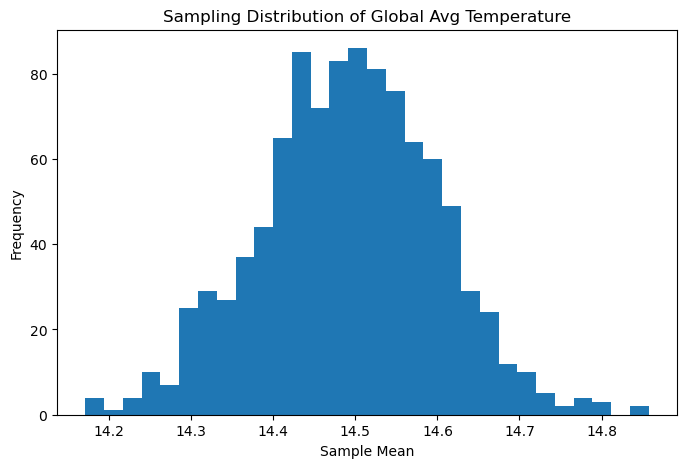

In [42]:
sample_means = []

for i in range(1000):
    sample = temp_data.sample(30, replace=True)
    sample_means.append(sample.mean())

plt.figure(figsize=(8,5))

plt.hist(sample_means, bins=30)

plt.title("Sampling Distribution of Global Avg Temperature")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")

plt.show()

# Conclusion

<h5 style="color: cyan; text-indent: 50px;">
    The statistical analysis of student grades shows that the distributions of the grades are approximately normal. The t-tests were used to compare mean grades across semesters. The paired t-test indicates whether students' performance changed from the first semester to the final semester.
<h5>